# Weather + Energy Demand Correlation — California 2023

## Overview
This project correlates Los Angeles daily temperatures from NOAA with California 
hourly electricity demand from the EIA API, aggregated to daily averages. 
The goal is to quantify how strongly temperature predicts electricity demand 
and identify the nature of that relationship.

**Data Sources:** EIA Open Data API, NOAA Climate Data Online API  
**Tools:** Python, pandas, requests, matplotlib, seaborn, scikit-learn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [2]:
EIA_KEY = "jxp5hkRHGqIrnKmwWgv8JjZlNmDMhS52cdKaFfZ3"
NOAA_KEY = "IIsvZVBQPjRPAuFcRPptTshJtBTDofos"

In [3]:
url = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

all_records = []

offsets = range(0, 9000, 5000)

for offset in offsets:
    params = {
        "api_key": EIA_KEY,
        "frequency": "hourly",
        "data[0]": "value",
        "facets[respondent][]": "CAL",
        "facets[type][]": "D",
        "start": "2023-01-01T00",
        "end": "2023-12-31T23",
        "length": 5000,
        "offset": offset
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    records = data["response"]["data"]
    
    if not records:
        break
        
    all_records.extend(records)
    print(f"Fetched offset {offset} — total records so far: {len(all_records)}")

print(f"Total records fetched: {len(all_records)}")

Fetched offset 0 — total records so far: 5000
Fetched offset 5000 — total records so far: 8760
Total records fetched: 8760


In [4]:
eia_df = pd.DataFrame(all_records)
eia_df = eia_df[["period", "value"]].copy()
eia_df.columns = ["datetime", "demand_mw"]
eia_df["datetime"] = pd.to_datetime(eia_df["datetime"])
eia_df["demand_mw"] = pd.to_numeric(eia_df["demand_mw"], errors="coerce")
eia_df = eia_df.sort_values("datetime").reset_index(drop=True)
print(f"Rows: {len(eia_df)}")
print(f"Date range: {eia_df['datetime'].min()} to {eia_df['datetime'].max()}")
eia_df.head()

Rows: 8760
Date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00


,datetime,demand_mw
0,2023-01-01 00:00:00,29324
1,2023-01-01 01:00:00,30063
2,2023-01-01 02:00:00,30945
3,2023-01-01 03:00:00,32041
4,2023-01-01 04:00:00,31455


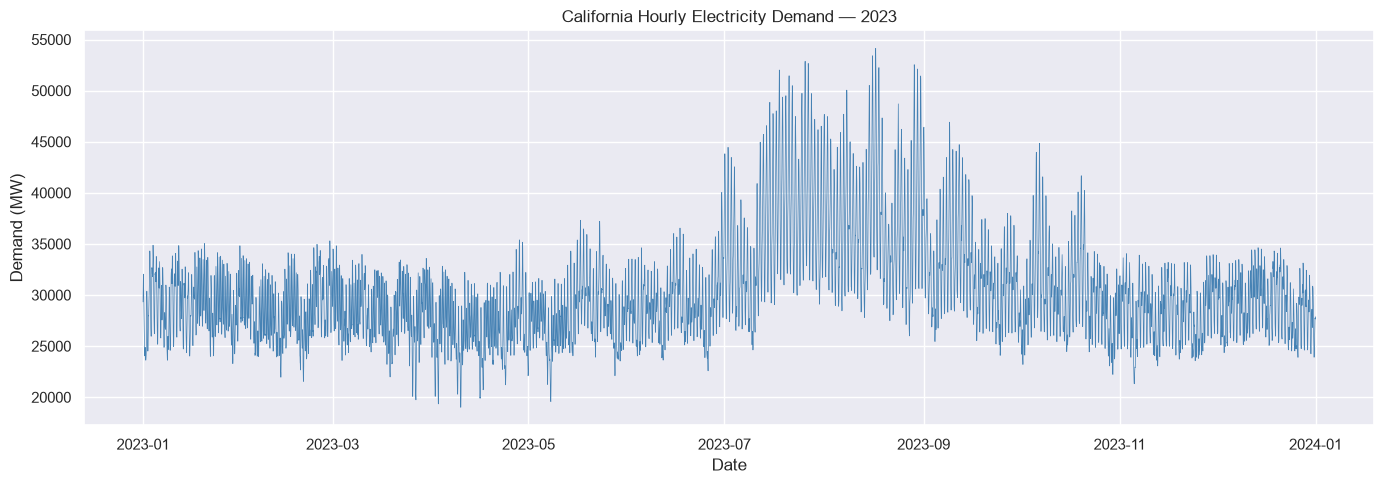

In [5]:
plt.plot(eia_df["datetime"], eia_df["demand_mw"], linewidth=0.5, color="steelblue")
plt.title("California Hourly Electricity Demand — 2023")
plt.ylabel("Demand (MW)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

## California Demand Pattern
Unlike eastern grids that show dual winter/summer peaks, California demand is 
dominated by a single summer peak driven by air conditioning load. The mild 
winters reduce heating-driven demand significantly. 

In [6]:
url = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data"
headers = {"token": NOAA_KEY}

all_weather = []

for datatype in ["TMAX", "TMIN"]:
    params = {
        "datasetid": "GHCND",
        "stationid": "GHCND:USW00023174",
        "datatypeid": datatype,
        "startdate": "2023-01-01",
        "enddate": "2023-12-31",
        "units": "standard",
        "limit": 1000
    }
    
    response = requests.get(url, headers=headers, params=params)
    results = response.json().get("results", [])
    all_weather.extend(results)
    print(f"Fetched {len(results)} rows for {datatype}")

print(f"Total weather records: {len(all_weather)}")

Fetched 365 rows for TMAX
Fetched 365 rows for TMIN
Total weather records: 730


In [7]:
weather_df = pd.DataFrame(all_weather)
weather_df = weather_df[["date", "datatype", "value"]].copy()
weather_df["date"] = pd.to_datetime(weather_df["date"])

weather_df = weather_df.pivot(index="date", columns="datatype", values="value")
weather_df.columns.name = None
weather_df = weather_df.reset_index()

# average daily temperature
weather_df["temp_avg_f"] = (weather_df["TMAX"] + weather_df["TMIN"]) / 2

weather_df.head()

,date,TMAX,TMIN,temp_avg_f
0,2023-01-01,61.0,54.0,57.5
1,2023-01-02,58.0,46.0,52.0
2,2023-01-03,58.0,50.0,54.0
3,2023-01-04,61.0,57.0,59.0
4,2023-01-05,62.0,55.0,58.5


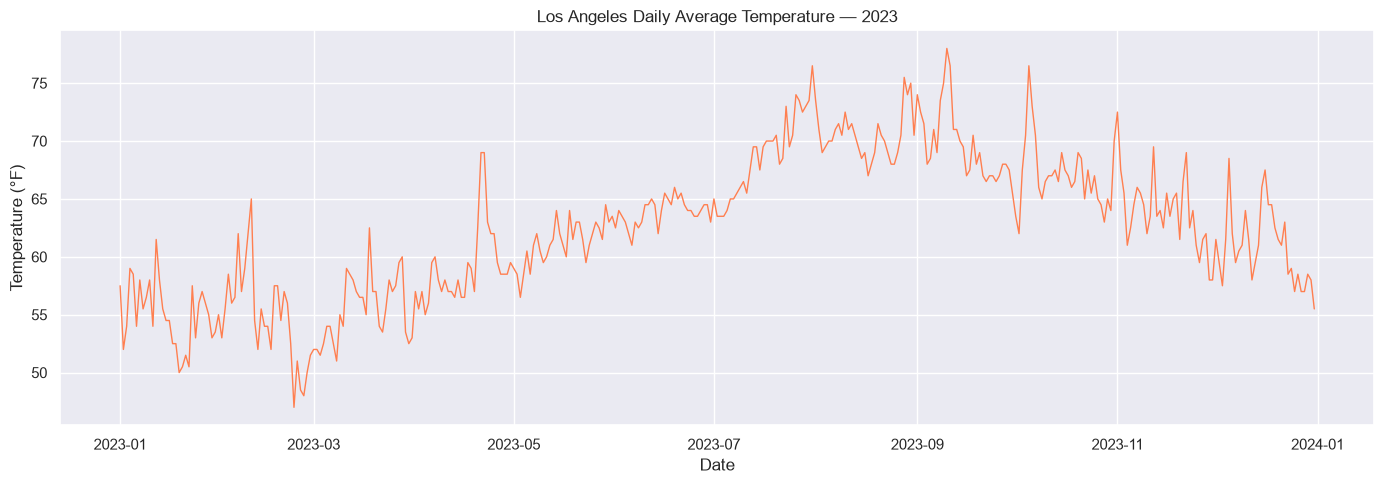

In [8]:
plt.plot(weather_df["date"], weather_df["temp_avg_f"], color="coral", linewidth=1)
plt.title("Los Angeles Daily Average Temperature — 2023")
plt.ylabel("Temperature (°F)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [9]:
eia_daily = eia_df.copy()
eia_daily["date"] = eia_daily["datetime"].dt.date
eia_daily["date"] = pd.to_datetime(eia_daily["date"])
eia_daily = eia_daily.groupby("date")["demand_mw"].mean().reset_index()
eia_daily.columns = ["date", "avg_demand_mw"]

eia_daily.head()

,date,avg_demand_mw
0,2023-01-01,26559.083333
1,2023-01-02,27603.750000
2,2023-01-03,30566.208333
3,2023-01-04,30777.333333
4,2023-01-05,30062.083333


In [10]:
merged_df = pd.merge(eia_daily, weather_df[["date", "temp_avg_f"]], on="date", how="inner")

print(f"Rows after merge: {len(merged_df)}")
merged_df.head()

Rows after merge: 365


,date,avg_demand_mw,temp_avg_f
0,2023-01-01,26559.083333,57.5
1,2023-01-02,27603.750000,52.0
2,2023-01-03,30566.208333,54.0
3,2023-01-04,30777.333333,59.0
4,2023-01-05,30062.083333,58.5


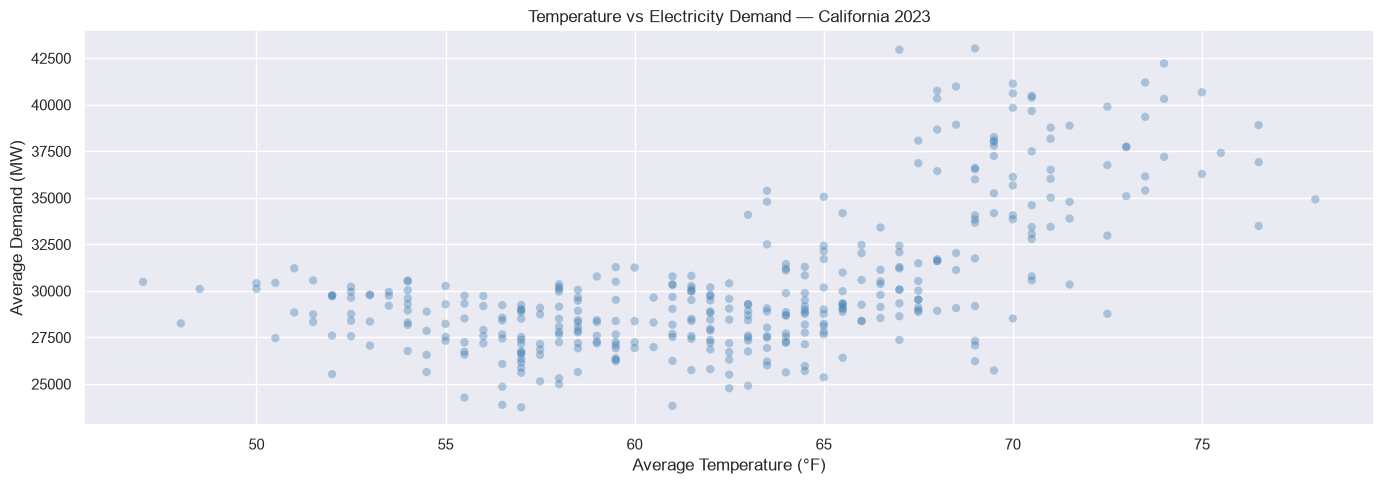

In [11]:
plt.scatter(merged_df["temp_avg_f"], merged_df["avg_demand_mw"], 
            alpha=0.4, color="steelblue", edgecolors="none")
plt.title("Temperature vs Electricity Demand — California 2023")
plt.xlabel("Average Temperature (°F)")
plt.ylabel("Average Demand (MW)")
plt.tight_layout()
plt.show()

R² score: 0.381


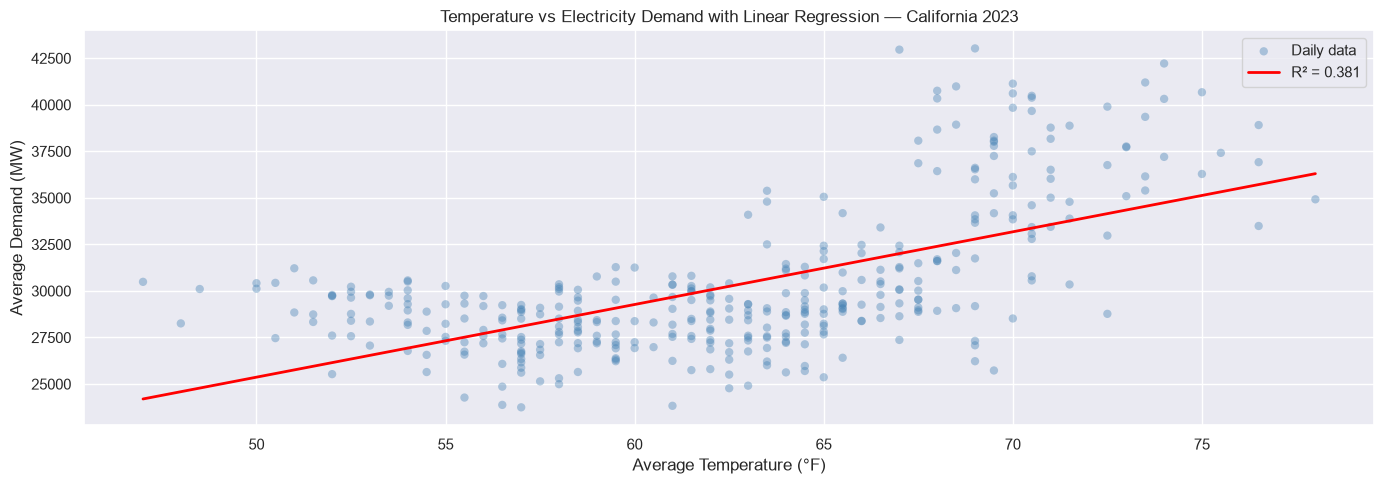

In [12]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = merged_df["temp_avg_f"].values.reshape(-1, 1)
y = merged_df["avg_demand_mw"].values

model = LinearRegression()
model.fit(X, y)

r_squared = model.score(X, y)
print(f"R² score: {r_squared:.3f}")

# Plot
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.scatter(merged_df["temp_avg_f"], merged_df["avg_demand_mw"],
            alpha=0.4, color="steelblue", edgecolors="none", label="Daily data")
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"R² = {r_squared:.3f}")
plt.title("Temperature vs Electricity Demand with Linear Regression — California 2023")
plt.xlabel("Average Temperature (°F)")
plt.ylabel("Average Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

Linear R²:     0.381
Polynomial R²: 0.531


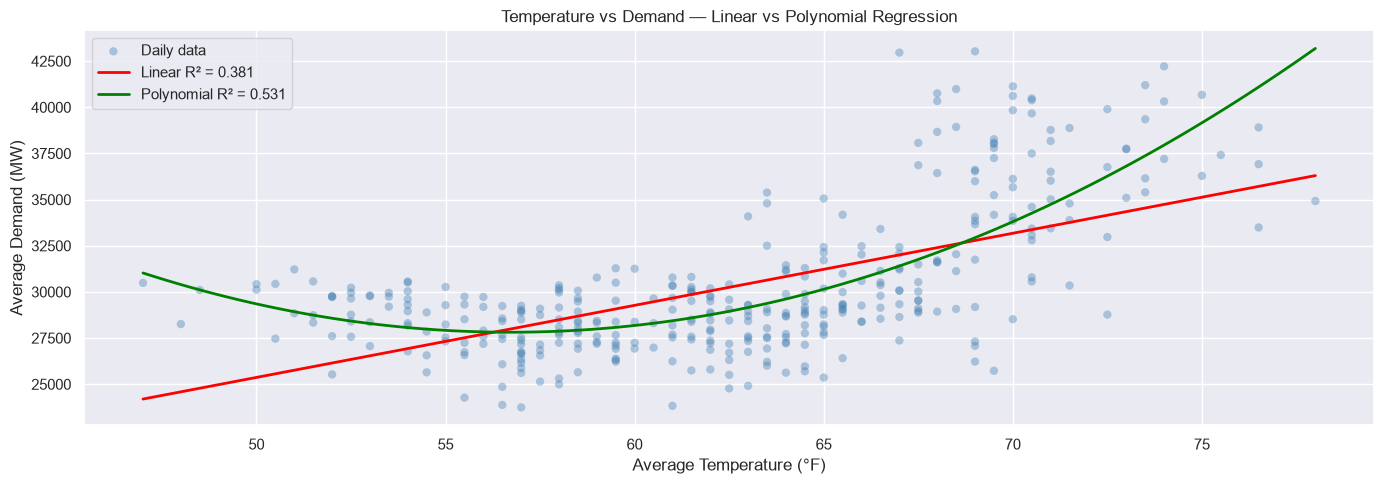

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Fit polynomial regression (degree 2 = curve)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X, y)

poly_r_squared = poly_model.score(X, y)
print(f"Linear R²:     {r_squared:.3f}")
print(f"Polynomial R²: {poly_r_squared:.3f}")

# Plot both
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_linear = model.predict(x_line)
y_poly = poly_model.predict(x_line)

plt.scatter(merged_df["temp_avg_f"], merged_df["avg_demand_mw"],
            alpha=0.4, color="steelblue", edgecolors="none", label="Daily data")
plt.plot(x_line, y_linear, color="red", linewidth=2, label=f"Linear R² = {r_squared:.3f}")
plt.plot(x_line, y_poly, color="green", linewidth=2, label=f"Polynomial R² = {poly_r_squared:.3f}")
plt.title("Temperature vs Demand — Linear vs Polynomial Regression")
plt.xlabel("Average Temperature (°F)")
plt.ylabel("Average Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

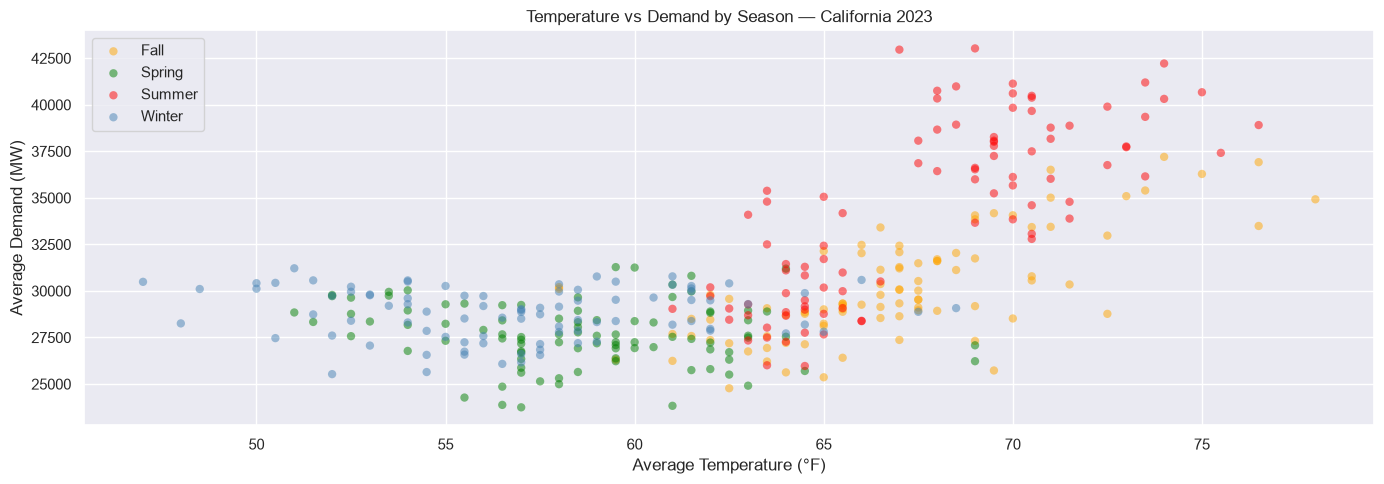

In [14]:
merged_df["month"] = merged_df["date"].dt.month
merged_df["season"] = merged_df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
})

season_colors = {"Winter": "steelblue", "Spring": "green", "Summer": "red", "Fall": "orange"}

for season, group in merged_df.groupby("season"):
    plt.scatter(group["temp_avg_f"], group["avg_demand_mw"],
                alpha=0.5, label=season, color=season_colors[season], edgecolors="none")

plt.title("Temperature vs Demand by Season — California 2023")
plt.xlabel("Average Temperature (°F)")
plt.ylabel("Average Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

## Key Findings

1. **Temperature and demand have a non-linear relationship.** Demand stays flat 
   in the 50–70°F range then rises sharply above 70°F, reflecting a cooling 
   threshold where air conditioning load kicks in aggressively.

2. **Linear regression underestimates the relationship** with an R² of 0.381. 
   A polynomial regression better captures the curve, improving R² to 0.531 — 
   meaning temperature alone explains over half of daily demand variation.

3. **California demand is cooling-driven, not heating-driven.** Unlike eastern 
   grids with dual winter/summer peaks, California shows a single summer peak 
   driven almost entirely by AC load, consistent with its mild winters.

4. **Seasonal patterns confirm temperature as the core driver.** Spring and Fall 
   overlap heavily in the scatter plot, confirming that calendar season matters 
   less than actual temperature in predicting demand.

## Techniques Used
- REST API calls with the requests library
- Paginated data fetching from EIA API
- Daily aggregation of hourly demand data
- Merging two DataFrames from different sources on timestamps
- Linear and polynomial regression with scikit-learn
- R² scoring to evaluate model fit